In [234]:
from joblib import load
import numpy as np

MODEL_PATH = "../src/training/dt_smote_pipeline_model.joblib"
MODEL = load(MODEL_PATH)

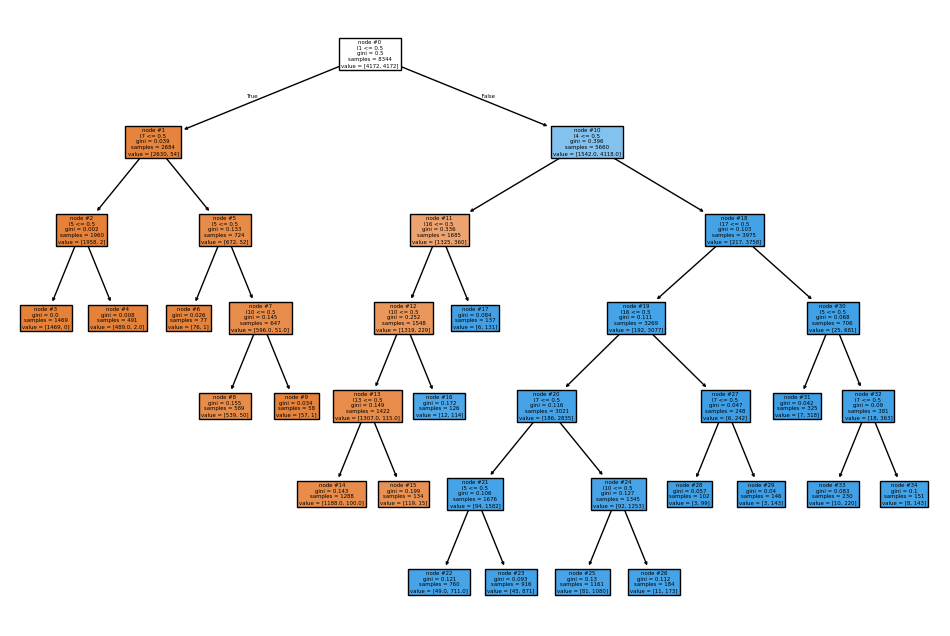

In [235]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

FEATURE_ORDER = ['E1', 'E10', 'E11', 'E12', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9',
                 'I1', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'I16', 'I17', 'I2', 'I3', 'I4',
                 'I5', 'I6', 'I7', 'I8', 'I9']

FEATURE_ORDER = ['I1', 'I10', 'I13', 'I16', 'I17', 'I4', 'I5', 'I7']
#FEATURE_ORDER = ['E1', 'E10', 'E11', 'E12', 'E2', 'E3', 'E5', 'E6', 'E7', 'E8', 'E9']

plt.figure(figsize=(12,8))
plot_tree(MODEL, filled=True, feature_names=FEATURE_ORDER, node_ids=True)
plt.savefig("decision_tree.png", dpi=600)
plt.show()


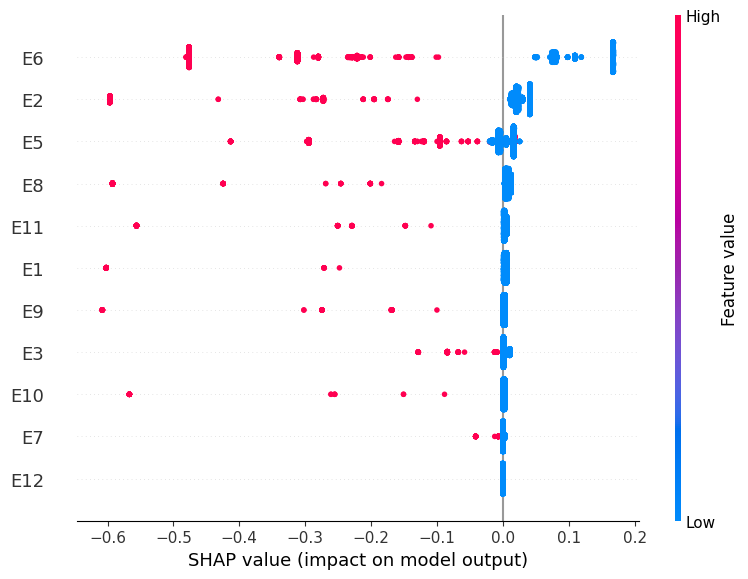

In [233]:
import shap

train_df = df[df["split"] == "train"]
X = train_df[FEATURE_ORDER]
y = train_df["label"]

# Explain the model's predictions using SHAP
explainer = shap.TreeExplainer(MODEL)
shap_values = explainer.shap_values(X)

# For binary classification, shap_values[1] is the impact on the "1" class
# Positive SHAP = pushes toward 1, Negative SHAP = pushes toward 0
shap.summary_plot(shap_values[:, :, 1], X)

In [208]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Calculate discriminativity (Information Gain)
# This returns a score for each feature (higher = more discriminative)
discrete_features = [True] * len(features_cols) # Since your data is categorical/binary
scores = mutual_info_classif(X, y, discrete_features=True)

# Create a summary
discriminativity_df = pd.DataFrame({
    'Feature': features_cols,
    'Discriminativity_Score': scores
}).sort_values(by='Discriminativity_Score', ascending=False)

print(discriminativity_df)

ValueError: All arrays must be of the same length

In [141]:
def identify_critical_nodes(tree, feature_names, threshold=0.9):
    tree_ = tree.tree_
    node_metadata = {}

    def get_leaf_stats(node):
        """Recursively find the sample counts and predictions in sub-leaves."""
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            pred = np.argmax(tree_.value[node][0])
            samples = tree_.n_node_samples[node]
            return {0: samples if pred == 0 else 0, 1: samples if pred == 1 else 0}
        
        left = get_leaf_stats(tree_.children_left[node])
        right = get_leaf_stats(tree_.children_right[node])
        return {0: left[0] + right[0], 1: left[1] + right[1]}

    for i in range(tree_.node_count):
        if tree_.feature[i] != _tree.TREE_UNDEFINED:
            feature = feature_names[tree_.feature[i]]
            
            # Analyze what happens if the LLM says "0" vs "1"
            left_stats = get_leaf_stats(tree_.children_left[i])
            right_stats = get_leaf_stats(tree_.children_right[i])
            
            # Calculate Risk: Percentage of samples in this branch that end in Exclude (0)
            total_left = sum(left_stats.values())
            total_right = sum(right_stats.values())

            if feature == "I01":
                print(left_stats)
                print(right_stats)
                print("left: ", total_left)
                print("right: ", total_right)
            
            risk_if_0 = left_stats[0] / total_left if total_left > 0 else 0
            risk_if_1 = right_stats[0] / total_right if total_right > 0 else 0

            node_metadata[i] = {
                "feature": feature,
                "is_critical": bool((risk_if_0 > threshold) or (risk_if_1 > threshold)),
                "risk_map": {0: risk_if_0.item(), 1: risk_if_1.item()}
            }
            
    return node_metadata

identify_critical_nodes(MODEL, feature_names=FEATURE_ORDER)

{0: np.int64(2678), 1: 0}
{0: np.int64(1412), 1: np.int64(4254)}
left:  2678
right:  5666


{0: {'feature': 'I01',
  'is_critical': True,
  'risk_map': {0: 1.0, 1: 0.2492057889163431}},
 1: {'feature': 'I07', 'is_critical': True, 'risk_map': {0: 1.0, 1: 1.0}},
 2: {'feature': 'I05', 'is_critical': True, 'risk_map': {0: 1.0, 1: 1.0}},
 4: {'feature': 'E06', 'is_critical': True, 'risk_map': {0: 1.0, 1: 1.0}},
 7: {'feature': 'E06', 'is_critical': True, 'risk_map': {0: 1.0, 1: 1.0}},
 8: {'feature': 'E02', 'is_critical': True, 'risk_map': {0: 1.0, 1: 1.0}},
 11: {'feature': 'E05', 'is_critical': True, 'risk_map': {0: 1.0, 1: 1.0}},
 12: {'feature': 'I09', 'is_critical': True, 'risk_map': {0: 1.0, 1: 1.0}},
 14: {'feature': 'I08', 'is_critical': True, 'risk_map': {0: 1.0, 1: 1.0}},
 17: {'feature': 'I08', 'is_critical': True, 'risk_map': {0: 1.0, 1: 1.0}},
 20: {'feature': 'I04',
  'is_critical': False,
  'risk_map': {0: 0.8495788206979543, 1: 0.0}},
 21: {'feature': 'I16',
  'is_critical': True,
  'risk_map': {0: 0.918075422626788, 1: 0.0}},
 22: {'feature': 'I10', 'is_critical'

In [205]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Suppose 'tree' is your trained DecisionTreeClassifier
dt = MODEL

# Compute depth of all nodes
node_depth = np.zeros(dt.tree_.node_count, dtype=int)
stack = [(0, 0)]  # (node_id, depth)
while stack:
    node_id, depth = stack.pop()
    node_depth[node_id] = depth
    left = dt.tree_.children_left[node_id]
    right = dt.tree_.children_right[node_id]
    if left != right:  # not a leaf
        stack.append((left, depth + 1))
        stack.append((right, depth + 1))

# Leaf nodes
leaf_nodes = np.where(dt.tree_.children_left == dt.tree_.children_right)[0]
leaf_depths = node_depth[leaf_nodes]

print("Leaf nodes:", leaf_nodes)
print("Leaf depths:", leaf_depths)
print("Average leaf depth:", np.mean(leaf_depths))


Leaf nodes: [ 3  5  6  9 10 11 16 17 18 19 24 25 27 28 30 31 33 35 36]
Leaf depths: [3 4 4 4 4 3 5 5 4 3 6 6 6 6 5 5 4 5 5]
Average leaf depth: 4.578947368421052


90
122
66
803


/Users/joshua/Desktop/Repositories/MedTech/random-forest-tiab-screening/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/joshua/Desktop/Repositories/MedTech/random-forest-tiab-screening/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/joshua/Desktop/Repositories/MedTech/random-forest-tiab-screening/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/joshua/Desktop/Repositories/MedTech/random-forest-tiab-screening/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTr

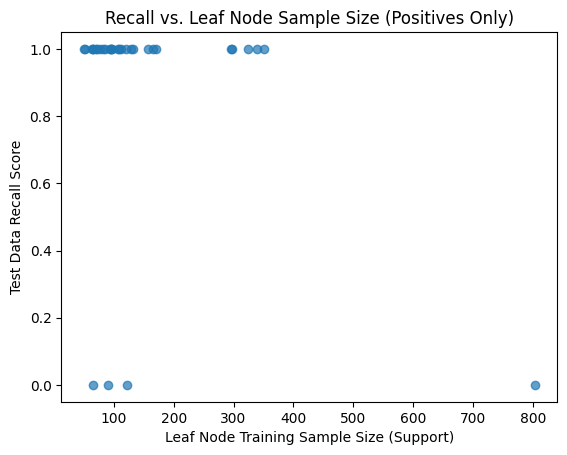

In [99]:
recalls = []
sample_sizes = []

for leaf in unique_leaves:
    mask = (leaf_indices == leaf)
    y_true_leaf = y_test[mask]
    
    # Skip leaves that have NO actual positive items in the test set
    if sum(y_true_leaf) == 0:
        continue
        
    y_pred_leaf = MODEL.predict(X_test[mask])
    
    # Calculate recall (we know there's at least one positive now)
    recall = recall_score(y_true_leaf, y_pred_leaf)
    recalls.append(recall)
    if recall == 0:
        print(MODEL.tree_.n_node_samples[leaf])
    
    # Get the number of training samples that formed this leaf
    sample_sizes.append(MODEL.tree_.n_node_samples[leaf])

# Plot the results
plt.scatter(sample_sizes, recalls, alpha=0.7)
plt.xlabel('Leaf Node Training Sample Size (Support)')
plt.ylabel('Test Data Recall Score')
plt.title('Recall vs. Leaf Node Sample Size (Positives Only)')
plt.show()

In [94]:
import numpy as np

# Find the node indices where the sample size is exactly 803
target_nodes = np.where(MODEL.tree_.n_node_samples == 803)[0]

print(f"Node indices with 803 training samples: {target_nodes}")


Node indices with 803 training samples: [30]


In [98]:
MODEL.tree_.value[node_id]

array([[0.88667497, 0.11332503]])

In [101]:
# Assuming X_test is a NumPy array
mask = (
    (X_test[:, 12] == 1) & 
    (X_test[:, 23] == 0) & 
    (X_test[:, 19] == 0) & 
    (X_test[:, 13] == 0) &
    (X_test[:, 21] == 0) & 
    (X_test[:, 25] == 0) & 
    (X_test[:, 28] == 0) & 
    (X_test[:, 10] == 0) & 
    (X_test[:, 7] == 0) 
)

test_samples_in_leaf = X_test[mask]
true_labels_in_leaf = y_test[mask]

print(f"Number of test samples that landed here: {len(test_samples_in_leaf)}")

Number of test samples that landed here: 194


In [102]:
true_labels_in_leaf

array([False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [89]:
# Assuming X_test is a NumPy array
mask = (
    (X_train[:, 12] == 0) & 
    (X_train[:, 19] == 0) & 
    (X_train[:, 26] == 0) & 
    (X_train[:, 24] == 0)
)

train_samples_in_leaf = X_train[mask]
true_labels_in_leaf = y_train[mask]

print(f"Number of train samples that landed here: {len(train_samples_in_leaf)}")

Number of train samples that landed here: 1446


In [ ]:
Update1 = "2021-02-10 00:00:00" # 974
Update2 = "2021-09-19 00:00:00" # 351
Update3 = "2022-03-06 00:00:00" # 323
Update4 = "2023-10-01 00:00:00" # 1113
Update5 = "2024-01-24 00:00:00" # 454
Update6 = "2024-07-26 00:00:00" # 584
Update7 = "2025-01-13 00:00:00" # 357

In [104]:
import unicodedata

text = "BACKGROUND: Screen\u2010based simulation..." # Your string

# "NFKD" separates combined characters, then we encode to ASCII and ignore errors
clean_text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

print(clean_text)

BACKGROUND: Screenbased simulation...


In [ ]:
llm = ChatOllama(
    model="qwen3:8b",
    temperature=0
)

llm = "gpt-5-nano"

agent = create_agent(
    model=llm,
    tools=[fetch_next_candidate_study, fetch_current_fulltext, fetch_report_fulltext, fetch_study_reports, fetch_study_interventions, fetch_study_persons, fetch_report_abstract],
    context_schema=Context,
    system_prompt=system_message,
    response_format=ToolStrategy(Output)
)